## Reproducing Henrich (2004): Demography and Cultural Evolution

This notebook reproduces the core mathematical arguments and figures from: 

> Joseph Henrich's paper *"Demography and Cultural Evolution: How Adaptive Cultural Processes Can Produce Maladaptive Losses - The Tasmanian Case"* (American Antiquity, 2004).

[link](https://www2.psych.ubc.ca/~henrich/Website/Papers/HenrichAmericanAntiquity2004.pdf)

## The Core Model

The paper argues that complex skills are maintained by a process of imperfect social learning.

* **Inaccurate Learning ():** Most learners will not be as good as the person they copy.
* **Variation ($\beta$):** Occasionally, a learner is "lucky" or talented and improves on the technique.
* **Selection ($$N$):** A larger population () increases the chances of finding a "lucky" learner who exceeds the current skill ceiling, preventing the technology from degrading.

The change in average skill ($\Delta \bar z$) is derived in the paper as:

Where:

* $\alpha$: The systematic error (tendency to degrade).
* $\beta$: The variability (potential for innovation).
* $\epsilon$: The Euler-Mascheroni constant ().
* $N$: The effective population of social learners.


### The Gumbel Distribution and Cultural Loss

Henrich's model assumes that the "errors" or "variations" in social learning follow a **Gumbel distribution** (also known as the Log-Weibull or Type I Extreme Value distribution). 

#### Why the Gumbel?
In the context of cultural evolution, the Gumbel distribution is used to model the skill level $z_i$ of a learner attempting to copy a model with skill $z_h$:
$$z_i = z_h + \epsilon_i$$
where $\epsilon_i \sim \text{Gumbel}(-\alpha, \beta)$.

1. **The "Loss" ($\alpha$):** Most learners will fail to perfectly replicate a complex skill. The parameter $\alpha$ represents this systematic degradation or "cost" of inaccurate imitation.
2. **The "Innovation" ($\beta$):** The Gumbel distribution has a heavy right tail. This means that while most learners lose skill, there is a small probability that a "lucky" or talented learner will actually *improve* upon the model's skill.
3. **The Power of Numbers ($N$):** A crucial property of the Gumbel distribution is that the expected maximum of $N$ independent draws increases with $\ln(N)$. In a larger population, you are more likely to find that one "lucky" individual who overcomes the systematic loss $\alpha$ and pushes the technology forward.


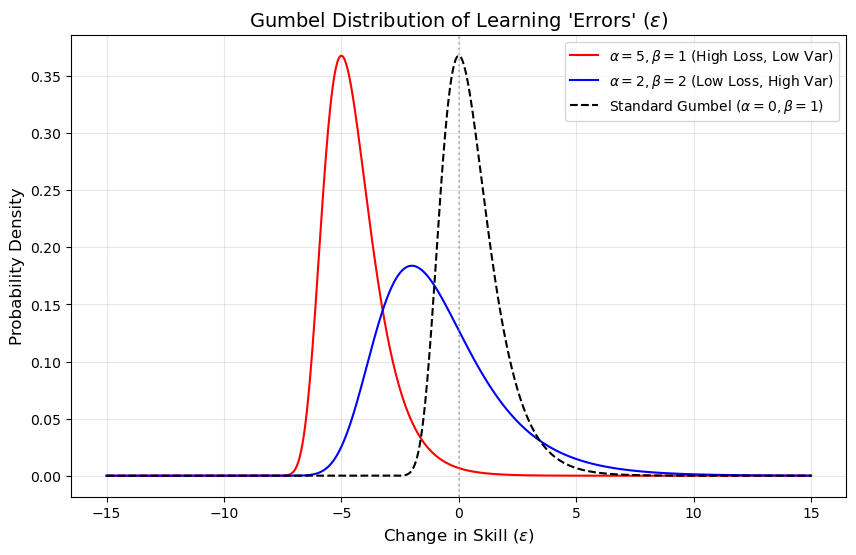

In [5]:
from scipy.stats import gumbel_r

# Parameters to illustrate
# alpha (loc) shifts the distribution left (loss)
# beta (scale) controls the width of the tail (innovation potential)
x = np.linspace(-15, 15, 1000)

plt.figure(figsize=(10, 6))

# Case 1: High loss, low variation (Hard to learn, low innovation)
plt.plot(x, gumbel_r.pdf(x, loc=-5, scale=1), label=r'$\alpha=5, \beta=1$ (High Loss, Low Var)', color='red')

# Case 2: Low loss, high variation (Easier to learn, high innovation)
plt.plot(x, gumbel_r.pdf(x, loc=-2, scale=2), label=r'$\alpha=2, \beta=2$ (Low Loss, High Var)', color='blue')

# Case 3: Standard Gumbel for reference
plt.plot(x, gumbel_r.pdf(x, loc=0, scale=1), label=r'Standard Gumbel ($\alpha=0, \beta=1$)', color='black', linestyle='--')

plt.axvline(0, color='grey', linestyle=':', alpha=0.5)
plt.title("Gumbel Distribution of Learning 'Errors' ($\epsilon$)", fontsize=14)
plt.xlabel("Change in Skill ($\epsilon$)", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Critical Population Threshold (N*): 170.22


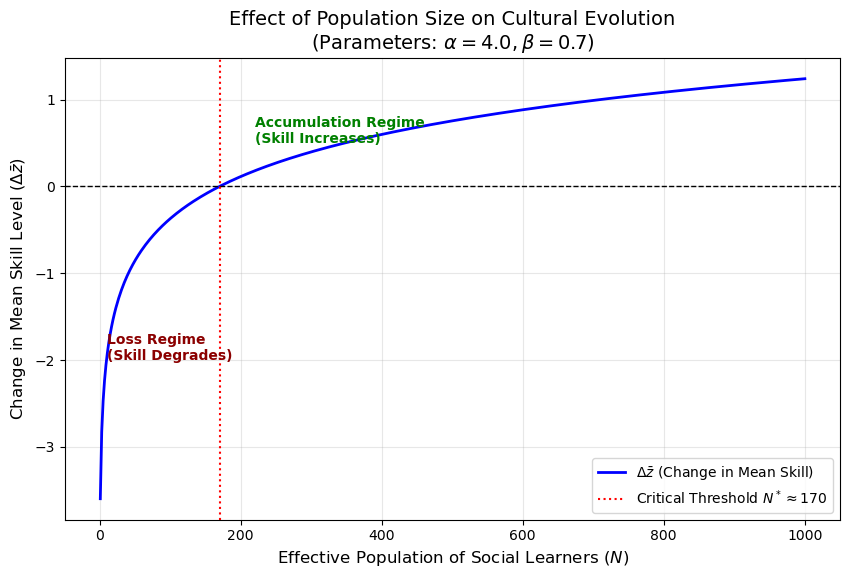

In [3]:

# 1. Parameter Setup
# These values are chosen to illustrate the effect, similar to those in the paper's theoretical discussion.
alpha = 4.0      # The cost of inaccurate imitation (tendency to lose skill)
beta = 0.7       # The spread/variability (potential for rare improvements)
euler_gamma = 0.57721 # Euler-Mascheroni constant

# 2. The Analytical Function
def change_in_skill(N, alpha, beta):
    """
    Calculates the expected change in mean skill (Delta z_bar)
    based on population size N.
    Equation: Delta z = -alpha + beta * (epsilon + ln(N))
    """
    return -alpha + beta * (euler_gamma + np.log(N))

# 3. Generate Data for Plotting
population_sizes = np.linspace(1, 1000, 500)
delta_z_values = change_in_skill(population_sizes, alpha, beta)

# Find the critical threshold (N*) where Delta z = 0
# 0 = -alpha + beta * (epsilon + ln(N*))
# alpha / beta = epsilon + ln(N*)
# ln(N*) = (alpha / beta) - epsilon
# N* = exp((alpha / beta) - epsilon)
critical_N = np.exp((alpha / beta) - euler_gamma)
print(f"Critical Population Threshold (N*): {critical_N:.2f}")

# 4. Plotting Figure 1: The Relationship between N and Skill Change
plt.figure(figsize=(10, 6))
plt.plot(population_sizes, delta_z_values, label=r'$\Delta \bar{z}$ (Change in Mean Skill)', color='blue', linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(critical_N, color='red', linestyle=':', label=fr'Critical Threshold $N^* \approx {int(critical_N)}$')

# Annotations
plt.text(critical_N + 50, 0.5, "Accumulation Regime\n(Skill Increases)", color='green', fontweight='bold')
plt.text(10, -2, "Loss Regime\n(Skill Degrades)", color='darkred', fontweight='bold')

plt.title(f"Effect of Population Size on Cultural Evolution\n(Parameters: $\\alpha={alpha}, \\beta={beta}$)", fontsize=14)
plt.xlabel("Effective Population of Social Learners ($N$)", fontsize=12)
plt.ylabel(r"Change in Mean Skill Level ($\Delta \bar{z}$)", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Simulation: Evolution Over Time

While the graph above shows the *rate* of change, the simulation below demonstrates what happens over many generations.

* **Scenario A (Blue):** A population () above the critical threshold. They should maintain or slowly improve their technology.
* **Scenario B (Red):** A population () below the critical threshold. Even though they are trying to copy the best, the lack of "lucky" high-end variants means the technology will slowly simplify and degrade until it is lost.

This mimics the "Tasmanian Effect" described in the paper: isolation led to a drop in effective population size, pushing them below the threshold for maintaining complex tools like bone points.



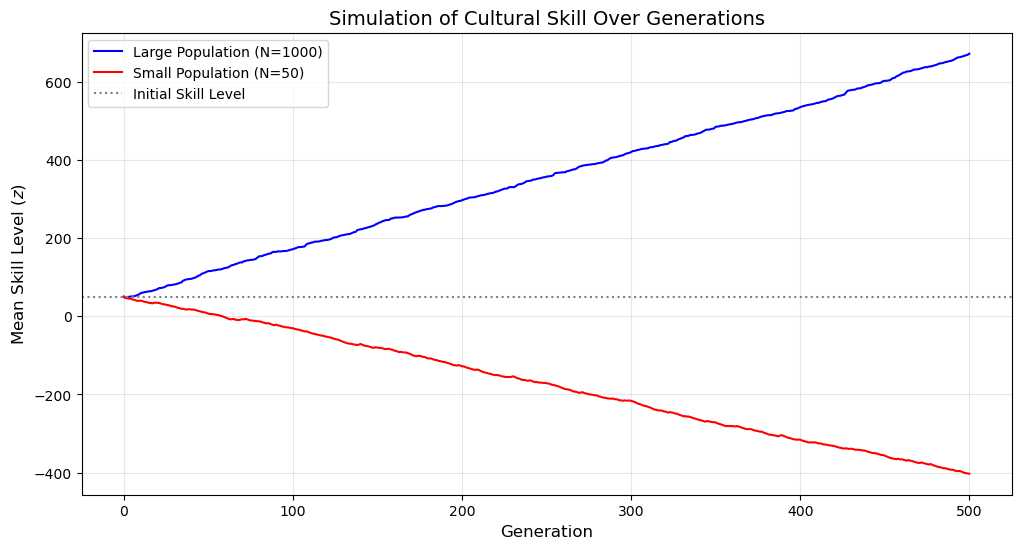

In [4]:

def run_simulation(N, generations, alpha, beta, initial_skill=100):
    """
    Simulates cultural evolution using the Gumbel distribution logic.
    """
    # Initialize population skills
    # We assume everyone starts with the same high skill level for simplicity
    current_skills = np.full(N, initial_skill, dtype=float)
    mean_skills_history = [np.mean(current_skills)]

    for gen in range(generations):
        # 1. Find the Model: The most skilled individual in the current generation
        z_h = np.max(current_skills)

        # 2. Social Learning (The Gumbel Process)
        # Each individual in the NEW generation tries to copy z_h.
        # Their skill is drawn from a Gumbel distribution determined by the model's skill.
        # According to the paper's appendix derivation:
        # The learner's skill z_i = z_h - epsilon + Gumbel_draw
        # However, to match the simplified recursive model:
        # z_new = z_h - alpha + beta * (random_gumbel_noise)

        # We simulate the noise directly using the Gumbel distribution.
        # In scipy/numpy, gumbel(loc, scale).
        # We want the expected loss to be alpha.
        # The paper simplifies this, but essentially we draw N new learners.

        # Let's use the direct recursive logic for the simulation to be robust:
        # Every learner attempts to copy the best (z_h).
        # Their resulting skill is z_h shifted by error.
        # Error is drawn from Gumbel(-alpha, beta).
        # Note: numpy.random.gumbel(loc, scale)
        # We center the distribution so the mean offset matches the paper's alpha.

        # Generating N new learners
        # The paper implies z_i ~ Gumbel(mode = z_h - alpha, scale = beta)
        new_skills = np.random.gumbel(loc=(z_h - alpha), scale=beta, size=N)

        current_skills = new_skills
        mean_skills_history.append(np.mean(current_skills))

    return mean_skills_history

# Simulation Parameters
generations = 500
alpha = 4.0
beta = 0.7
start_skill = 50

# Run for different population sizes
history_large = run_simulation(N=1000, generations=generations, alpha=alpha, beta=beta, initial_skill=start_skill)
history_small = run_simulation(N=50, generations=generations, alpha=alpha, beta=beta, initial_skill=start_skill)

# Plotting Figure 2: Trajectories over Time
plt.figure(figsize=(12, 6))

plt.plot(history_large, label='Large Population (N=1000)', color='blue')
plt.plot(history_small, label='Small Population (N=50)', color='red')

plt.title("Simulation of Cultural Skill Over Generations", fontsize=14)
plt.xlabel("Generation", fontsize=12)
plt.ylabel("Mean Skill Level ($z$)", fontsize=12)
plt.axhline(start_skill, color='grey', linestyle=':', label='Initial Skill Level')

plt.legend()
plt.grid(alpha=0.3)
plt.show()